# Replacement-Dynamics Adoption Model

This notebook builds a vehicle adoption model that follows the logic discussed in the meeting.

## Core idea

We separate the problem into two pieces:

1. **Sales share can change quickly**
   - The mix of newly entering vehicles can change a lot over time, especially for EVs.
   - We model this with a historical **adoption rate** computed from the yearly sales share by category.

2. **Fleet composition changes more slowly**
   - The total fleet does not explode exponentially because vehicles are replaced gradually.
   - We keep the fleet size close to a stable long-run path using the historical average **net annual fleet change**.

## Modeling assumptions

For each future year:

- We estimate the **sales share** of each vehicle type using historical adoption rates.
- We estimate how many **new vehicles enter** the fleet using the historical average yearly entries.
- We estimate the **total fleet net change** using the historical average yearly fleet change.
- From that, we infer the number of **vehicles leaving the fleet**:
  - `exits = entries - net_change`
- We add new vehicles according to the forecasted sales share.
- We remove vehicles proportionally to the current fleet composition.

This means:

- sales share can evolve fast,
- but fleet share evolves smoothly,
- because replacement takes time.

## Important note on infinity values

When a historical share is zero, the usual growth-rate formula can produce `inf`.

In this notebook, those values are replaced by `0` before averaging, which avoids the previous instability.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

PROJECT_DIR = Path('/Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model')
CACHE_DIR = PROJECT_DIR / '.cache'

FLEET_COUNTS_CACHE = CACHE_DIR / 'saq_vehicle_counts.pkl'
ENTRY_FULL_CACHE = CACHE_DIR / 'saq_entry_full.pkl'
ENTRY_COUNTS_CACHE = CACHE_DIR / 'saq_entry_counts.pkl'
FLAG_COMPARISON_CACHE = CACHE_DIR / 'saq_entry_flag_comparison.pkl'

fleet_counts = pd.read_pickle(FLEET_COUNTS_CACHE)
entry_full = pd.read_pickle(ENTRY_FULL_CACHE)
entry_counts = pd.read_pickle(ENTRY_COUNTS_CACHE)
flag_comparison = pd.read_pickle(FLAG_COMPARISON_CACHE)

fleet_counts.head()

,fsa,AnneeSAAQ,vehicle_type,count
0,G0A,2013,electric,10
1,G0A,2013,hev_sedan,144
2,G0A,2013,hev_suv,38
3,G0A,2013,ice_sedan,28633
4,G0A,2013,ice_suv,18244


## Settings

You can change these values if you want to test alternatives.

In [2]:
ENTRY_FLAG = 'Entrant'  # alternative: 'Neuf'
FORECAST_END_YEAR = 2035
USE_RECENT_YEARS_ONLY = False
RECENT_YEAR_START = 2016

# Optional guardrail for extreme adoption rates.
# Example: 1.0 means max +100% and min -100% annual share growth before averaging.
CLIP_ADOPTION_RATE = None  # set to a number like 1.0 if needed

ENTRY_FLAG, FORECAST_END_YEAR, USE_RECENT_YEARS_ONLY, CLIP_ADOPTION_RATE

('Entrant', 2035, False, None)

## Step 1: Historical Fleet Counts

We start from the observed fleet by year and by vehicle type.

In [3]:
fleet_yearly = (
    fleet_counts.groupby(['AnneeSAAQ', 'vehicle_type'], as_index=False)['count']
    .sum()
)

fleet_pivot = (
    fleet_yearly.pivot(index='AnneeSAAQ', columns='vehicle_type', values='count')
    .fillna(0)
    .sort_index()
)
fleet_pivot['total_vehicles'] = fleet_pivot.sum(axis=1)
vehicle_cols = [c for c in fleet_pivot.columns if c != 'total_vehicles']

fleet_pivot

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup,total_vehicles
AnneeSAAQ,,,,,,,
2013,563,16896,3962,2537595,1381891,335113,4276020
2014,1480,21608,4824,2531937,1436920,339103,4335872
2015,2813,25137,5706,2518363,1506361,344445,4402825
2016,4444,29380,8091,2503583,1583549,353948,4482995
2017,7706,34887,11073,2470262,1676234,367845,4568007
2018,15551,41930,16086,2396573,1750031,372382,4592553
2019,29340,51364,22956,2327602,1833058,377683,4642003
2020,43232,57352,30879,2271121,1930104,395913,4728601


## Step 2: Historical Sales Share (Entries)

We compute the yearly mix of newly entering vehicles. This is the part of the system that can evolve rapidly.

In [4]:
entry_by_year_type = (
    entry_counts.groupby(['AnneeSAAQ', 'vehicle_type'], as_index=False)[ENTRY_FLAG]
    .sum()
    .rename(columns={ENTRY_FLAG: 'entry_count'})
)
entry_by_year_type['entry_share'] = entry_by_year_type.groupby('AnneeSAAQ')['entry_count'].transform(lambda s: s / s.sum())

entry_share_pivot = (
    entry_by_year_type.pivot(index='AnneeSAAQ', columns='vehicle_type', values='entry_share')
    .fillna(0)
    .sort_index()
)
entry_share_pivot

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup
AnneeSAAQ,,,,,,
2013,0.001130,0.012233,0.002170,0.555115,0.361320,0.068032
2014,0.002573,0.013961,0.002545,0.535750,0.377395,0.067776
2015,0.003648,0.010883,0.002555,0.501907,0.398370,0.082636
2016,0.004580,0.013579,0.006828,0.448346,0.422134,0.104533
2017,0.008763,0.015851,0.008127,0.419497,0.441662,0.106101
2018,0.021566,0.021248,0.014270,0.384817,0.461488,0.096610
2019,0.038860,0.029447,0.019592,0.330164,0.488650,0.093288
2020,0.045805,0.022544,0.025593,0.286118,0.518920,0.101020


## Step 3: Historical Adoption Rates of Sales Share

For each category and year, we compute:

`adoption_rate_t = (share_t - share_(t-1)) / share_(t-1)`

If the previous share is zero, this creates `inf`. We replace `inf`, `-inf`, and `NaN` with `0`.

This is exactly the guardrail requested in the discussion.

In [5]:
adoption_rate = entry_share_pivot.pct_change()
adoption_rate = adoption_rate.replace([np.inf, -np.inf], 0).fillna(0)

if CLIP_ADOPTION_RATE is not None:
    adoption_rate = adoption_rate.clip(lower=-CLIP_ADOPTION_RATE, upper=CLIP_ADOPTION_RATE)

adoption_rate

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup
AnneeSAAQ,,,,,,
2013,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2014,1.277064,0.141231,0.172781,-0.034884,0.044492,-0.003774
2015,0.417667,-0.220440,0.004070,-0.063170,0.055578,0.219263
2016,0.255453,0.247735,1.672132,-0.106716,0.059652,0.264981
2017,0.913453,0.167298,0.190159,-0.064345,0.046260,0.014993
2018,1.461147,0.340444,0.756024,-0.082669,0.044889,-0.089447
2019,0.801856,0.385876,0.372902,-0.142024,0.058857,-0.034387
2020,0.178728,-0.234423,0.306319,-0.133405,0.061946,0.082881


In [6]:
adoption_source = adoption_rate.copy()
if USE_RECENT_YEARS_ONLY:
    adoption_source = adoption_source[adoption_source.index >= RECENT_YEAR_START]

avg_adoption_rate = adoption_source.mean()
avg_adoption_summary = pd.DataFrame({
    'vehicle_type': avg_adoption_rate.index,
    'avg_adoption_rate': avg_adoption_rate.values,
    'avg_adoption_rate_pct': avg_adoption_rate.values * 100,
}).sort_values('avg_adoption_rate', ascending=False)
avg_adoption_summary

,vehicle_type,avg_adoption_rate,avg_adoption_rate_pct
0,electric,0.663171,66.317116
2,hev_suv,0.434298,43.429839
1,hev_sedan,0.103465,10.346507
5,ice_van/pickup,0.056814,5.681384
4,ice_suv,0.046459,4.645933
3,ice_sedan,-0.078402,-7.840161


## Step 4: Historical Fleet Net Change

The total fleet is assumed to remain relatively stable. Instead of exponential growth, we estimate a smooth yearly net change directly from the observed fleet size:

`net_change_t = total_fleet_t - total_fleet_(t-1)`

Then we use the **average yearly net change** for the future.

In [7]:
fleet_change = fleet_pivot[['total_vehicles']].diff().rename(columns={'total_vehicles': 'fleet_net_change'})
fleet_change['fleet_growth_rate'] = fleet_pivot['total_vehicles'].pct_change()
fleet_change

vehicle_type,fleet_net_change,fleet_growth_rate
AnneeSAAQ,,
2013,NaN,NaN
2014,59852.0,0.013997
2015,66953.0,0.015442
2016,80170.0,0.018209
2017,85012.0,0.018963
2018,24546.0,0.005373
2019,49450.0,0.010767
2020,86598.0,0.018655


In [8]:
fleet_change_source = fleet_change.dropna().copy()
if USE_RECENT_YEARS_ONLY:
    fleet_change_source = fleet_change_source[fleet_change_source.index >= RECENT_YEAR_START]

avg_net_change = fleet_change_source['fleet_net_change'].mean()
avg_growth_rate = fleet_change_source['fleet_growth_rate'].mean()

pd.DataFrame({
    'metric': ['avg_net_change_vehicles', 'avg_growth_rate'],
    'value': [avg_net_change, avg_growth_rate],
})

,metric,value
0,avg_net_change_vehicles,64654.428571
1,avg_growth_rate,0.014487


## Step 5: Historical Entries per Year

We also need the absolute number of new vehicles entering the fleet each year, because market share changes through those additions.

In [9]:
entries_total = entry_full.groupby('AnneeSAAQ', as_index=False)[ENTRY_FLAG].sum().rename(columns={ENTRY_FLAG: 'entries_total'})
entries_total

,AnneeSAAQ,entries_total
0,2013,355757
1,2014,355998
2,2015,367078
3,2016,364228
4,2017,375681
5,2018,367052
6,2019,357698
7,2020,317739


In [10]:
entries_source = entries_total.copy()
if USE_RECENT_YEARS_ONLY:
    entries_source = entries_source[entries_source['AnneeSAAQ'] >= RECENT_YEAR_START].copy()

avg_entries_per_year = entries_source['entries_total'].mean()
avg_entries_per_year

357653.875

## Step 6: Future Sales Share Projection

We start from the last observed sales share and update it with the average historical adoption rate:

`share_(t+1) = share_t * (1 + avg_adoption_rate)`

Then we:

- clip negative values to `0`
- renormalize so the shares sum to `1`

This allows EV sales share to change faster than fleet share, while still keeping a valid probability vector each year.

In [11]:
last_observed_year = int(fleet_pivot.index.max())
future_years = list(range(last_observed_year + 1, FORECAST_END_YEAR + 1))

sales_share_future = entry_share_pivot.copy()
current_sales_share = sales_share_future.loc[last_observed_year, vehicle_cols].astype(float).copy()

for year in future_years:
    next_share = current_sales_share * (1 + avg_adoption_rate.reindex(vehicle_cols).fillna(0))
    next_share = next_share.clip(lower=0)
    if next_share.sum() > 0:
        next_share = next_share / next_share.sum()
    else:
        next_share = current_sales_share.copy()

    sales_share_future.loc[year, vehicle_cols] = next_share
    current_sales_share = next_share.copy()

sales_share_future = sales_share_future.sort_index()
sales_share_future.tail(15)

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup
AnneeSAAQ,,,,,,
2021,0.072468,0.023664,0.034919,0.250834,0.516560,0.101556
2022,0.112037,0.024273,0.046557,0.214885,0.502483,0.099766
2023,0.167993,0.024147,0.060202,0.178541,0.474062,0.095054
2024,0.242224,0.023100,0.074859,0.142650,0.430078,0.087088
2025,0.333140,0.021079,0.088788,0.108714,0.372171,0.076108
2026,0.434645,0.018246,0.099900,0.078595,0.305517,0.063096
2027,0.537410,0.014968,0.106522,0.053848,0.237680,0.049572
2028,0.632181,0.011682,0.108063,0.035101,0.175919,0.037054
2029,0.712874,0.008740,0.105087,0.021933,0.124816,0.026550


## Step 7: Replacement-Dynamics Fleet Forecast

For each future year:

1. `entries = average yearly entries`
2. `net_change = average yearly fleet net change`
3. `exits = entries - net_change`
4. add entries using the forecasted **sales share**
5. remove exits using the **current fleet share**

Using the current fleet share for removals is a replacement assumption:

- the fleet turns over slowly,
- so the stock composition changes more smoothly than sales.


In [12]:
projected_counts = fleet_pivot.copy()
current_counts = projected_counts.loc[last_observed_year, vehicle_cols].astype(float).copy()

projection_rows = []

for year in future_years:
    entries = float(avg_entries_per_year)
    exits = max(entries - avg_net_change, 0.0)

    current_fleet_share = current_counts / current_counts.sum()
    forecast_sales_share = sales_share_future.loc[year, vehicle_cols].astype(float)

    additions = entries * forecast_sales_share
    removals = exits * current_fleet_share

    next_counts = (current_counts + additions - removals).clip(lower=0)
    next_total = next_counts.sum()

    projected_counts.loc[year, vehicle_cols] = next_counts
    projected_counts.loc[year, 'total_vehicles'] = next_total

    projection_rows.append({
        'year': year,
        'entries': entries,
        'exits': exits,
        'net_change': entries - exits,
        'projected_total_vehicles': next_total,
    })

    current_counts = next_counts.copy()

projection_summary = pd.DataFrame(projection_rows)
projected_market_share = projected_counts[vehicle_cols].div(projected_counts[vehicle_cols].sum(axis=1), axis=0)
projection_summary

,year,entries,exits,net_change,projected_total_vehicles
0,2021,357653.875,292999.446429,64654.428571,4.793255e+06
1,2022,357653.875,292999.446429,64654.428571,4.857910e+06
2,2023,357653.875,292999.446429,64654.428571,4.922564e+06
3,2024,357653.875,292999.446429,64654.428571,4.987219e+06
4,2025,357653.875,292999.446429,64654.428571,5.051873e+06
5,2026,357653.875,292999.446429,64654.428571,5.116528e+06
6,2027,357653.875,292999.446429,64654.428571,5.181182e+06
7,2028,357653.875,292999.446429,64654.428571,5.245836e+06
8,2029,357653.875,292999.446429,64654.428571,5.310491e+06
9,2030,357653.875,292999.446429,64654.428571,5.375145e+06


## Main Tables

In [13]:
avg_adoption_summary

,vehicle_type,avg_adoption_rate,avg_adoption_rate_pct
0,electric,0.663171,66.317116
2,hev_suv,0.434298,43.429839
1,hev_sedan,0.103465,10.346507
5,ice_van/pickup,0.056814,5.681384
4,ice_suv,0.046459,4.645933
3,ice_sedan,-0.078402,-7.840161


In [14]:
projection_summary

,year,entries,exits,net_change,projected_total_vehicles
0,2021,357653.875,292999.446429,64654.428571,4.793255e+06
1,2022,357653.875,292999.446429,64654.428571,4.857910e+06
2,2023,357653.875,292999.446429,64654.428571,4.922564e+06
3,2024,357653.875,292999.446429,64654.428571,4.987219e+06
4,2025,357653.875,292999.446429,64654.428571,5.051873e+06
5,2026,357653.875,292999.446429,64654.428571,5.116528e+06
6,2027,357653.875,292999.446429,64654.428571,5.181182e+06
7,2028,357653.875,292999.446429,64654.428571,5.245836e+06
8,2029,357653.875,292999.446429,64654.428571,5.310491e+06
9,2030,357653.875,292999.446429,64654.428571,5.375145e+06


In [15]:
projected_counts.tail(15)

vehicle_type,electric,hev_sedan,hev_suv,ice_sedan,ice_suv,ice_van/pickup,total_vehicles
AnneeSAAQ,,,,,,,
2021,6.647171e+04,62261.669153,41454.630405,2.220107e+06,1.995258e+06,407702.718186,4.793255e+06
2022,1.024790e+05,67136.998043,55571.805511,2.161252e+06,2.053008e+06,418462.455510,4.857910e+06
2023,1.563814e+05,71724.072523,73751.654397,2.094754e+06,2.098733e+06,427219.829302,4.922564e+06
2024,2.337058e+05,75716.833526,96135.385495,2.021090e+06,2.127632e+06,432938.429880,4.987219e+06
2025,3.391244e+05,78807.413647,122242.843179,1.941233e+06,2.135742e+06,434723.594138,5.051873e+06
2026,4.749084e+05,80762.625934,150882.590021,1.856755e+06,2.121142e+06,432076.841278,5.116528e+06
2027,6.399195e+05,81491.170866,180340.222424,1.769686e+06,2.084682e+06,425063.285214,5.181182e+06
2028,8.298337e+05,81060.999714,208791.026435,1.682163e+06,2.029710e+06,414278.001783,5.245836e+06
2029,1.038447e+06,79659.399875,234714.209441,1.596052e+06,1.960984e+06,400634.698948,5.310491e+06


## Plot 1: Historical Fleet Size and Smoothed Future Fleet

This should show that total vehicles evolve smoothly, without exponential blow-up.

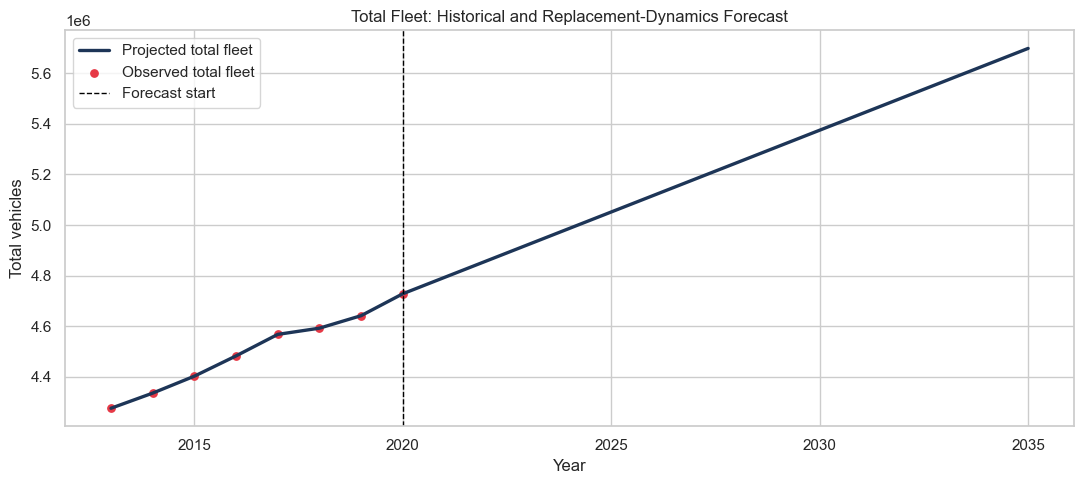

In [16]:
plt.figure(figsize=(11, 5))
plt.plot(projected_counts.index, projected_counts['total_vehicles'], linewidth=2.4, color='#1d3557', label='Projected total fleet')
plt.scatter(fleet_pivot.index, fleet_pivot['total_vehicles'], color='#e63946', s=28, label='Observed total fleet')
plt.axvline(last_observed_year, linestyle='--', color='black', linewidth=1, label='Forecast start')
plt.xlabel('Year')
plt.ylabel('Total vehicles')
plt.title('Total Fleet: Historical and Replacement-Dynamics Forecast')
plt.legend()
plt.tight_layout()
plt.show()

## Plot 2: Historical and Future Sales Share

This shows the part of the model that can change more rapidly.

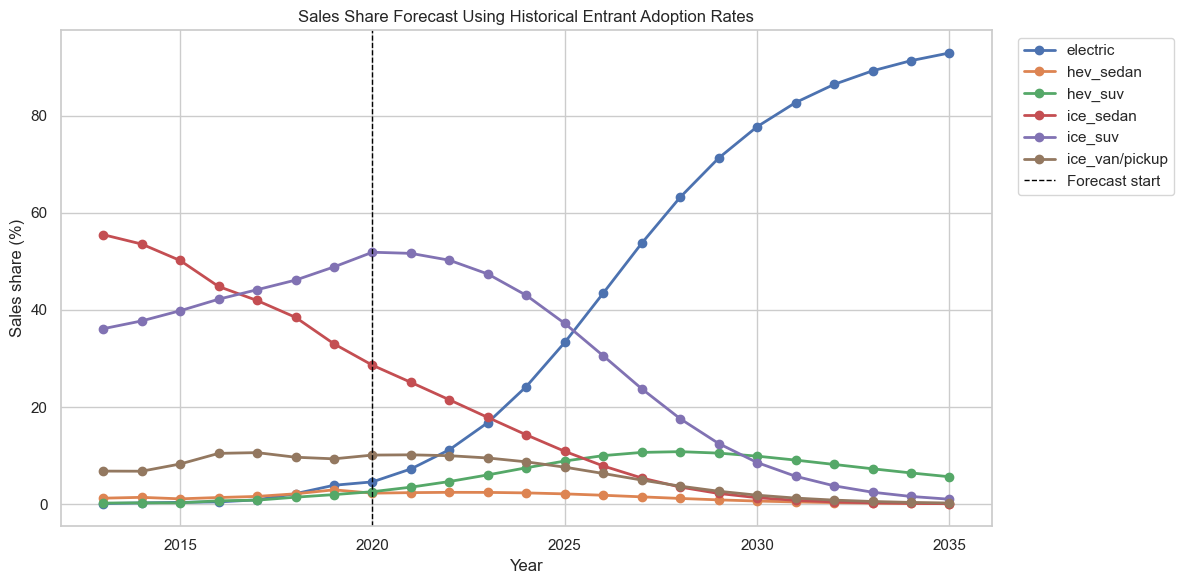

In [17]:
plt.figure(figsize=(12, 6))
for vehicle_type in vehicle_cols:
    plt.plot(sales_share_future.index, sales_share_future[vehicle_type] * 100, marker='o', linewidth=2, label=vehicle_type)
plt.axvline(last_observed_year, linestyle='--', color='black', linewidth=1, label='Forecast start')
plt.xlabel('Year')
plt.ylabel('Sales share (%)')
plt.title(f'Sales Share Forecast Using Historical {ENTRY_FLAG} Adoption Rates')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Plot 3: Fleet Market Share

This is the key output. Fleet market share changes more smoothly than sales share because the fleet turns over gradually.

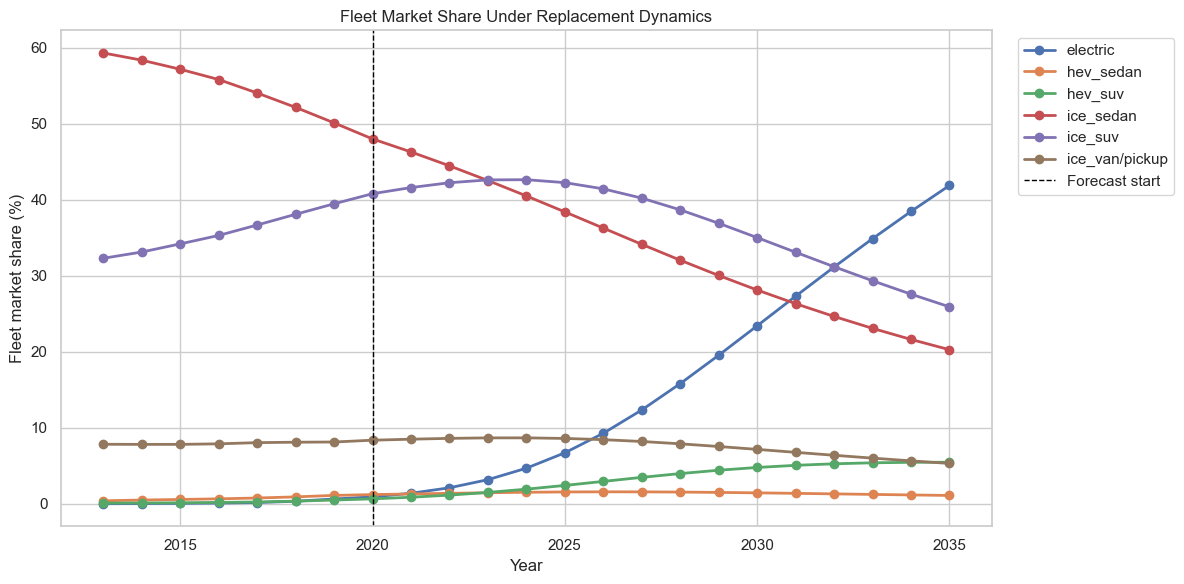

In [18]:
plt.figure(figsize=(12, 6))
for vehicle_type in vehicle_cols:
    plt.plot(projected_market_share.index, projected_market_share[vehicle_type] * 100, marker='o', linewidth=2, label=vehicle_type)
plt.axvline(last_observed_year, linestyle='--', color='black', linewidth=1, label='Forecast start')
plt.xlabel('Year')
plt.ylabel('Fleet market share (%)')
plt.title('Fleet Market Share Under Replacement Dynamics')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Plot 4: Vehicle Counts by Type

This lets you check whether the category trajectories are behaving reasonably.

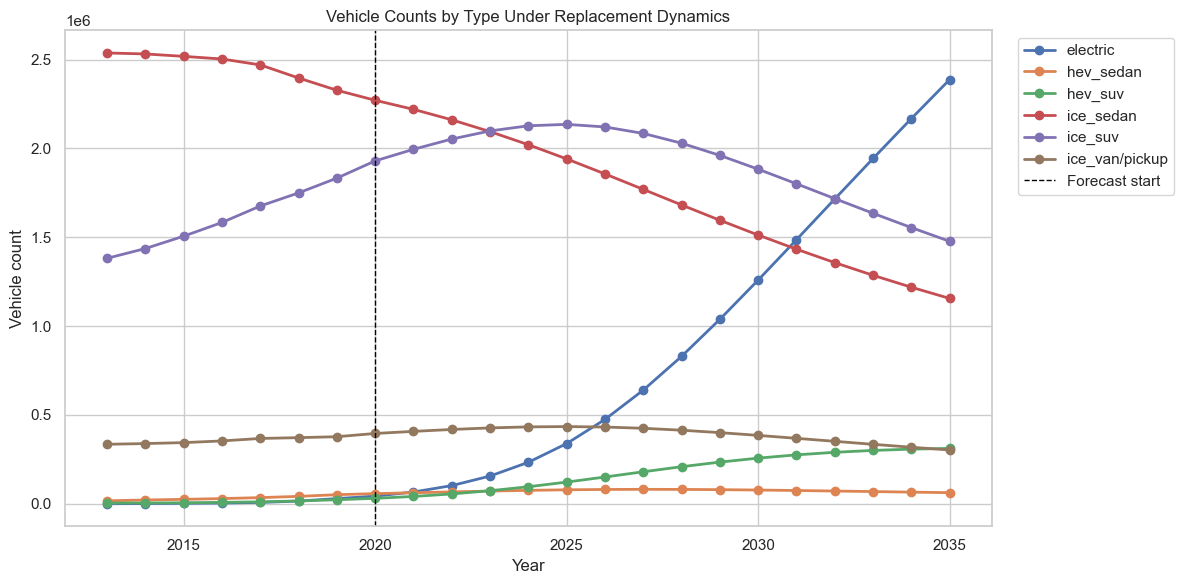

In [19]:
plt.figure(figsize=(12, 6))
for vehicle_type in vehicle_cols:
    plt.plot(projected_counts.index, projected_counts[vehicle_type], marker='o', linewidth=2, label=vehicle_type)
plt.axvline(last_observed_year, linestyle='--', color='black', linewidth=1, label='Forecast start')
plt.xlabel('Year')
plt.ylabel('Vehicle count')
plt.title('Vehicle Counts by Type Under Replacement Dynamics')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Plot 5: Historical Entries and Fleet Net Change

This plot is useful to see the difference between:

- how many vehicles are entering,
- and how much the total fleet is actually changing.

That gap is what creates replacement dynamics.

/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/natomanzolli/opt/anaconda3/envs/bus_charging_app/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/natomanzolli/opt/anaconda

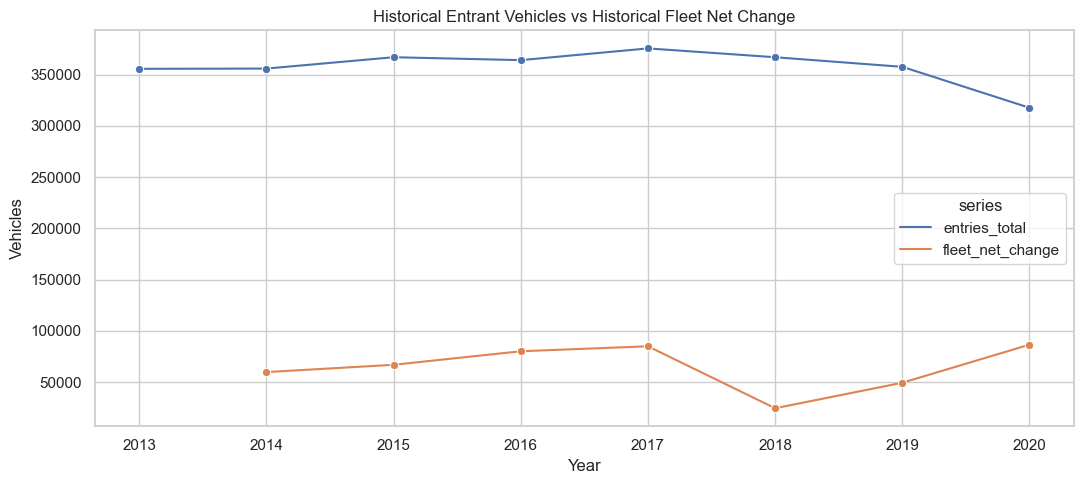

In [20]:
compare_df = entries_total.merge(
    fleet_change.reset_index()[['AnneeSAAQ', 'fleet_net_change']],
    on='AnneeSAAQ',
    how='left'
)
compare_long = compare_df.melt(id_vars='AnneeSAAQ', value_vars=['entries_total', 'fleet_net_change'], var_name='series', value_name='value')

plt.figure(figsize=(11, 5))
sns.lineplot(data=compare_long, x='AnneeSAAQ', y='value', hue='series', marker='o')
plt.xlabel('Year')
plt.ylabel('Vehicles')
plt.title(f'Historical {ENTRY_FLAG} Vehicles vs Historical Fleet Net Change')
plt.tight_layout()
plt.show()

## Optional: Save Outputs

In [21]:
output_dir = PROJECT_DIR / 'validation_outputs' / 'replacement_dynamics_adoption_model'
output_dir.mkdir(parents=True, exist_ok=True)

avg_adoption_summary.to_csv(output_dir / 'average_adoption_rates.csv', index=False)
entries_total.to_csv(output_dir / f'historical_{ENTRY_FLAG.lower()}_totals.csv', index=False)
projection_summary.to_csv(output_dir / 'projection_summary.csv', index=False)
sales_share_future.to_csv(output_dir / 'projected_sales_share.csv')
projected_counts.to_csv(output_dir / 'projected_fleet_counts.csv')
projected_market_share.to_csv(output_dir / 'projected_fleet_market_share.csv')

print(f'Saved outputs to {output_dir}')

Saved outputs to /Users/natomanzolli/Documents/GitHub/MATSim-agent-vehicle-assignment/adoption prediction model/validation_outputs/replacement_dynamics_adoption_model
